## Evaluate pretrained model

In [27]:
from transformers import Dinov2Model
from torchvision import transforms
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
NUM_CLASSES = 10  # CIFAR-10
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

#train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
#test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
dataset = CutsAnglesDataset('../data/case_1.2_cuts/cuts_0-14620.npy', '../data/case_1.2_cuts/cut_angles_0-14620.npy', transform = transform)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model = dinov2_vits14.to(DEVICE)
model = Dinov2Model.from_pretrained("facebook/dinov2-base")
model = model.to(DEVICE)
model.eval()

def extract_features(dataloader):
    features = []
    labels = []
    with torch.no_grad():
        i = 0
        for images, targets in tqdm(dataloader):
            images = images.to(DEVICE)
            outputs = model(images)
            cls_features = outputs.last_hidden_state[:, 0, :]  # CLS token
            features.append(cls_features.cpu())
            labels.append(targets)
            i+=1
    return torch.cat(features), torch.cat(labels)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Extracting train features...")
train_features, train_labels = extract_features(train_loader)


Using cache found in /Users/goldsteyn.kd/.cache/torch/hub/facebookresearch_dinov2_main


Extracting train features...


  0%|                                                                                                                                                                                         | 0/366 [00:00<?, ?it/s]


AttributeError: 'Tensor' object has no attribute 'last_hidden_state'

In [65]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform1 = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(140),
    transforms.CenterCrop(140), #should be multiple of model patch_size
    transforms.ToTensor(),
    transforms.Normalize(mean=0.5, std=0.2)
])

dataset = CutsAnglesDataset('../data/case_1.2_cuts/cuts_0-14620.npy', '../data/case_1.2_cuts/cut_angles_0-14620.npy', transform = transform1)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model = dinov2_vits14.to(DEVICE)
model.eval()

#scaler = MinMaxScaler(clip=True)
patch_size = dinov2_vits14.patch_size

patch_h  = 140//patch_size
patch_w  = 140//patch_size
feat_dim = 384 # vitl14

def extract_features(dataloader):
    features = []
    labels = []
    with torch.no_grad():
        i = 0
        for images, targets in tqdm(dataloader):
            images = images.to(DEVICE)
    
            #features_dict = dinov2_vits14.forward_features(images)
            #print(features_dict.keys())
            #feature = features_dict['x_norm_clstoken']
            #features.append(feature)
            outputs = model(images)
            #print(outputs.shape)
            #cls_features = outputs.last_hidden_state[:, 0, :]  # CLS token
            features.append(outputs.cpu())
            labels.append(targets)
            i+=1
    return torch.cat(features), torch.cat(labels)
    
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Extracting train features...")
train_features, train_labels = extract_features(train_loader)
#dinov2_vits14.forward_features(img_t.unsqueeze(0))
#features_dict = dinov2_vits14.forward_features(img_t.unsqueeze(0))
#features = features_dict['x_norm_patchtokens']

Using cache found in /Users/goldsteyn.kd/.cache/torch/hub/facebookresearch_dinov2_main


Extracting train features...


  0%|▍                                                                                                                                                                                | 1/366 [00:00<01:42,  3.55it/s]

dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


  1%|▉                                                                                                                                                                                | 2/366 [00:00<01:36,  3.75it/s]

...

dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


 99%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ | 364/366 [01:28<00:00,  4.24it/s]

dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 366/366 [01:28<00:00,  4.13it/s]

dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])
dict_keys(['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks'])


In [2]:
from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix


import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import datasets, models, transforms

import numpy as np
from tqdm import tqdm

In [66]:
train_features.shape

torch.Size([11696, 384])

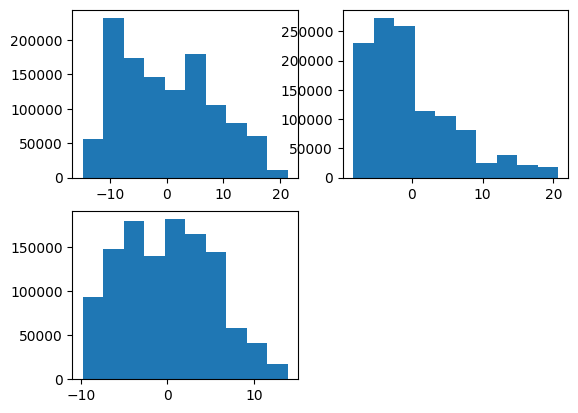

In [56]:
pca = PCA(n_components=3)
scaler = MinMaxScaler(clip=True)
patch_size = dinov2_vits14.patch_size

patch_h  = 140//patch_size
patch_w  = 140//patch_size
feat_dim = 384

total_features = train_features.reshape(train_features.shape[0] * patch_h * patch_w, feat_dim) #4(*H*w, 1024)
total_features = total_features.cpu()

pca.fit(total_features)
pca_features = pca.transform(total_features)

# visualize PCA components for finding a proper threshold
# 3 histograms for 3 components
plt.subplot(2, 2, 1)
plt.hist(pca_features[:, 0])
plt.subplot(2, 2, 2)
plt.hist(pca_features[:, 1])
plt.subplot(2, 2, 3)
plt.hist(pca_features[:, 2])
plt.show()
plt.close()

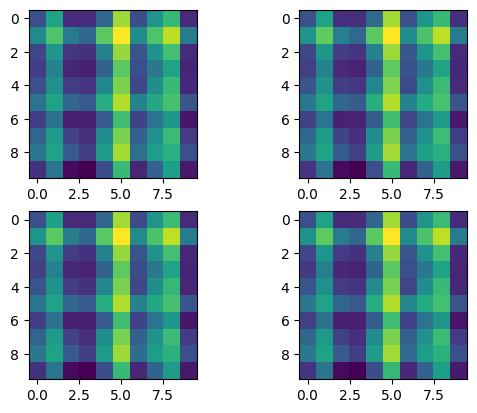

In [57]:
pca_features[:, 0] = (pca_features[:, 0] - pca_features[:, 0].min()) / \
                     (pca_features[:, 0].max() - pca_features[:, 0].min())
# pca_features = sklearn.processing.minmax_scale(pca_features)

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(pca_features[i*patch_h*patch_w : (i+1)*patch_h*patch_w, 0].reshape(patch_h, patch_w))

plt.show()

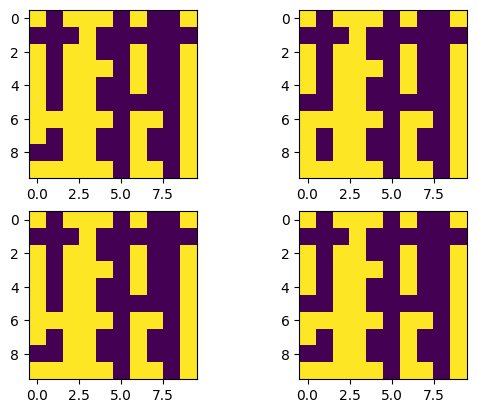

In [58]:
pca_features_bg = pca_features[:, 0] < 0.4 # from first histogram
pca_features_fg = ~pca_features_bg

# plot the pca_features_bg
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(pca_features_bg[i * patch_h * patch_w: (i+1) * patch_h * patch_w].reshape(patch_h, patch_w))
plt.show()


In [18]:
#train_features.shape
A = np.load('../data/case_1.2_cuts/cuts_0-14620.npy')
print(A[:,0,:,:].max())

1.0


Epoch [4/20]:   0%|                                                                                                                                                               | 0/366 [00:00<?, ?it/s, loss=0.493]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Epoch [9/20]:  74%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                                      | 272/366 [00:00<00:00, 656.28it/s, loss=0.329]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_

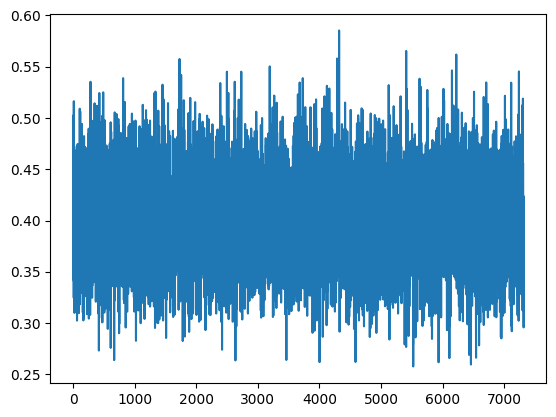

In [67]:
class DinoRegressor(nn.Module):
    def __init__(self):
        super(DinoRegressor, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.classifier(x)
        return x

f_dataset = FeaturesAnglesDataset(train_features, train_labels)
f_loader = DataLoader(f_dataset, batch_size=32, shuffle=True)
    
model = DinoRegressor()
model = model.to(DEVICE)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

num_epoch = 20
losses = []
for epoch in range(num_epoch):
    train_acc = 0
    train_loss = 0
    loop = tqdm(f_loader)
    for features, labels in loop:
        features = features.to(DEVICE).float()
        labels = labels.to(DEVICE).float()

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        losses.append(loss.item())
        predictions = outputs

        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch [{epoch}/{num_epoch}]")
        loop.set_postfix(loss=loss.item())

plt.plot(losses)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 366/366 [00:00<00:00, 4749.86it/s]


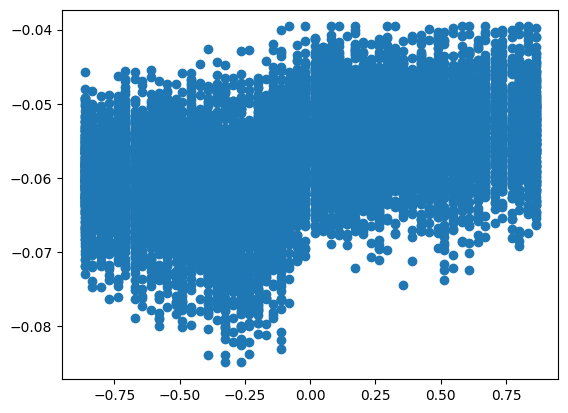

In [68]:
lbs = []
outs = []
with torch.no_grad():
    loop = tqdm(f_loader)
    for features, labels in loop:
        features = features.to(DEVICE).float()
        labels = labels.to(DEVICE).float()
        lbs.append(labels)
        outputs = model(features)
        outs.append(outputs)
labels = torch.cat(lbs)
outputs = torch.cat(outs)
labels = labels.numpy()
outputs = outputs.numpy()
plt.scatter(labels, outputs)
#plt.plot([-1,1],[-1,1])

In [71]:
from sklearn.svm import LinearSVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_regression
#X, y = make_regression(n_features=4, random_state=0)
regr = make_pipeline(StandardScaler(),
                     LinearSVR(random_state=0, tol=1e-5))
regr.fit(train_features, train_labels)

/Users/goldsteyn.kd/.pyenv/versions/3.11.6/lib/python3.11/site-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/goldsteyn.kd/.pyenv/versions/3.11.6/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/goldsteyn.kd/.pyenv/versions/3.11.6/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


ValueError: Expected 2D array, got 1D array instead:
array=[ 3.59633207e+00  1.79294801e+00  8.21809173e-02 -3.08340162e-01
  8.63813043e-01 -7.15954185e-01  1.63481712e+00 -1.09498739e+00
 -2.89111972e+00  1.46790481e+00 -2.62568295e-01 -6.81236863e-01
 -1.79786766e+00 -3.04849744e-01 -7.33790934e-01 -3.23139310e+00
 -2.46400666e+00 -3.92653704e-01 -1.09966815e+00 -3.21002173e+00
  2.52155852e+00  2.75616717e+00 -7.46027112e-01  6.20909929e-01
  1.89259875e+00 -1.62274003e+00  9.14088666e-01  1.53559566e-01
  1.53321266e+00 -4.76362467e-01  1.32581681e-01  1.81205738e+00
  1.39204764e+00  1.15281105e+00 -9.90475774e-01  1.53690076e+00
  1.06618285e+00 -3.84768414e+00 -3.64521313e+00  7.80827463e-01
 -4.90844280e-01  1.21352816e+00 -1.49660468e+00  4.11544609e+00
 -1.07296026e+00  7.40726292e-01  8.41733277e-01  1.24439812e+00
 -1.06595322e-01  1.38376009e+00  2.18193698e+00  9.65955496e-01
 -1.41262138e+00  7.70626307e-01 -1.90682673e+00  1.21662998e+00
 -1.27834415e+00  3.75520349e-0

-0.21886775505471645


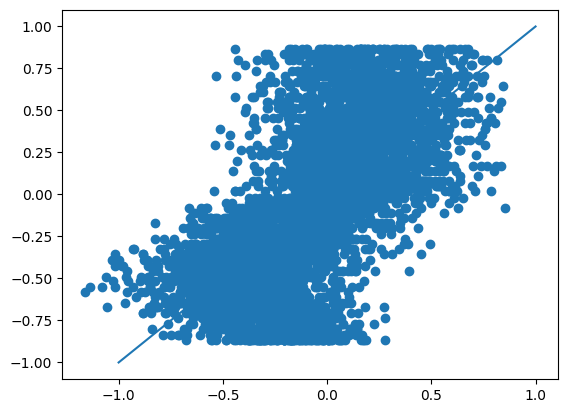

In [80]:
from sklearn.metrics import r2_score
outputs = []
labels = []
for i in range(5000):
    outputs.append(regr.predict([train_features[i]]))
    labels.append(train_labels[i].item())
plt.scatter(outputs,labels)
plt.plot([-1,1],[-1,1])
print(r2_score(outputs,labels))
#print(regr.predict([train_features[0]]), train_labels[0])

## Initialize from-scratch model

In [1]:
import torch
import torch.nn as nn
import math

class DINOV2Analog(nn.Module):
    def __init__(self, in_channels=3, patch_size=16, 
                 embed_dim=768, num_heads=6, num_layers=6,
                 base_img_size=224):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        
        # calculate number of patches
        self.base_num_patches = (base_img_size // patch_size) ** 2
        
        # patch Embedding
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, 
                                   kernel_size=patch_size, 
                                   stride=patch_size)
        
        # CLS token and positional encoding
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.base_num_patches + 1, embed_dim)  # +1 for CLS
        )
        
        # transformer encoder
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio=4, qkv_bias=True)
            for _ in range(num_layers)
        ])
        
        # projection Head
        self.proj_head = nn.Sequential(
            nn.Linear(embed_dim, 4096),
            nn.GELU(),
            nn.Linear(4096, 256),
            nn.LayerNorm(256)
        )
        
        self.norm = nn.LayerNorm(embed_dim)
        self.init_weights()

    def init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        
    def forward(self, x):
        B, C, H, W = x.shape
        
        # calculate number of patches
        P_H, P_W = H // self.patch_size, W // self.patch_size
        num_patches = P_H * P_W
        
        # patch embedding
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)  # [B, N, D]
        
        # add CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        
        # positional embedding with interpolation
        pos_embed = self.interpolate_pos_encoding(P_H, P_W)
        x = x + pos_embed
        
        # Transformer blocks
        for blk in self.blocks:
            x = blk(x)
        
        x = self.norm(x)
        
        return {
            'cls_token': x[:, 0],
            'all_tokens': x[:, 1:],
            'projection': self.proj_head(x[:, 0])
        }

    def interpolate_pos_encoding(self, pH, pW):
        current_num_patches = pH * pW
        
        if current_num_patches == self.base_num_patches:
            return self.pos_embed
        
        # split CLS and patch embeddings
        cls_pos = self.pos_embed[:, :1, :]
        patch_pos = self.pos_embed[:, 1:, :]
        
        # reshape to spatial dimensions
        patch_pos = patch_pos.transpose(1, 2).reshape(
            1, self.embed_dim, 
            int(self.base_num_patches**0.5), 
            int(self.base_num_patches**0.5)
        )
        
        # interpolate spatial embeddings
        patch_pos = F.interpolate(
            patch_pos,
            size=(pH, pW),
            mode="bilinear",
            align_corners=False,
        )
        
        # re-flatten and combine with CLS
        patch_pos = patch_pos.flatten(2).transpose(1, 2)
        return torch.cat([cls_pos, patch_pos], dim=1)

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=True):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio))
        
    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, in_dim)
        
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))


if __name__ == "__main__":
    model = DINOV2Analog(in_channels=3, patch_size=16)
    x = torch.randn(2, 3, 224, 224) 
    outputs = model(x)
    
    print("CLS token shape:", outputs['cls_token'].shape)       # [2, 768]
    print("All tokens shape:", outputs['all_tokens'].shape)     # [2, 196, 768]
    print("Projection shape:", outputs['projection'].shape)     # [2, 256]

CLS token shape: torch.Size([2, 768])
All tokens shape: torch.Size([2, 196, 768])
Projection shape: torch.Size([2, 256])


In [82]:
test = test_features[0].resize(16,16,3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


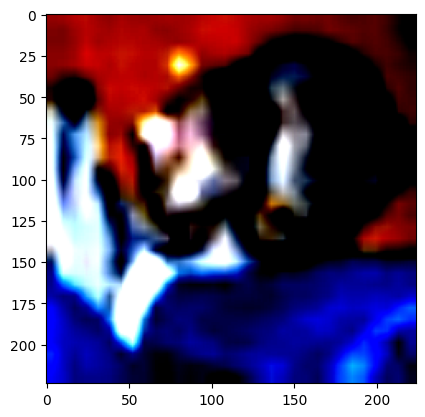

In [75]:
plt.imshow(test_dataset[0][0].movedim(0,-1))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


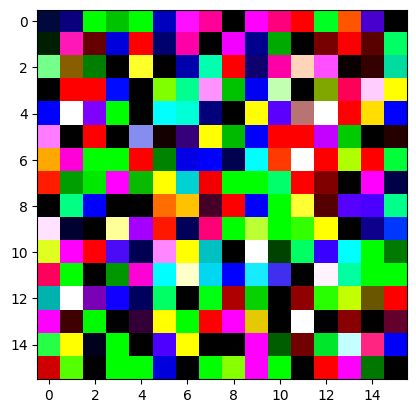

In [84]:
plt.imshow(test)

In [16]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as transforms
#A = np.load('../data/case_1.2_cuts/cuts_0-14620.npy')
class CutsDataset(Dataset):
    def __init__(self, file_path, transform = None):
        """
        Args:
            file_path (string): Path to the .npy file containing the images.
        """
        self.data = np.load(file_path)  
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image = self.data[idx] 
        image = torch.from_numpy(image).float() 
        if self.transform:
            image = self.transform(image)
        return image

class CutsAnglesDataset(Dataset):
    def __init__(self, cuts_path, angles_path, transform = None):
        """
        Args:
            file_path (string): Path to the .npy file containing the images.
        """
        self.data = np.load(cuts_path)
        for i in range(1,self.data.shape[1]):
            self.data[:,i,:,:] = self.data[:,0,:,:]
        self.data = self.data*255
        self.transform = transform
        self.targets = np.load(angles_path)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image = self.data[idx]  
        target = self.targets[idx]
        image = torch.from_numpy(image).float() 
        if self.transform:
            image = self.transform(image)
        return image, target

class FeaturesAnglesDataset(Dataset):
    def __init__(self, features, angles):
        """
        Args:
            file_path (string): Path to the .npy file containing the images.
        """
        self.data = features
        self.targets = angles
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        features = self.data[idx]  
        angles = self.targets[idx]
        return features, angles


class MultiCropTransform:
    def __init__(self):
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(224, antialias=True),  # For tensors
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
            transforms.GaussianBlur(kernel_size=3),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(96, antialias=True),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
            transforms.GaussianBlur(kernel_size=1),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, image):
        return [
            self.global_transform(image),
            self.global_transform(image),
            self.local_transform(image),
            self.local_transform(image)
        ]

dataset = CutsDataset('../data/case_1.2_cuts/cuts_0-14620.npy', transform = MultiCropTransform())
#dataset = CutsAnglesDataset('../data/case_1.2_cuts/cuts_0-14620.npy', '../data/case_1.2_cuts/cut_angles_0-14620.npy', transform = MultiCropTransform())

dataloader = DataLoader(
    dataset,
    batch_size=32,    
    shuffle=True,    
)

In [49]:
A = np.load('../data/case_1.2_cuts/cut_angles_0-14620.npy')
print(max(A))

[0.86325465]


## Train from-scratch model

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms.v2 as transforms
#from torchvision import datasets, transforms
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
LR = 3e-4
WEIGHT_DECAY = 0.04
WARMUP_EPOCHS = 10
NUM_EPOCHS = 100
MOMENTUM_TEACHER = 0.996  # EMA parameter for teacher update
'''
# Data Augmentation (Multi-crop DINO-style)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.4, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MultiCropTransform:
    def __init__(self):
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.4, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.GaussianBlur(1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(96, scale=(0.05, 0.4)),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.GaussianBlur(1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, image):
        return [
            self.global_transform(image),
            self.global_transform(image),
            self.local_transform(image),
            self.local_transform(image)
        ]

train_transform = MultiCropTransform()

train_dataset = datasets.CIFAR10(root='./data', train=True, 
                               download=True, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                        shuffle=True, num_workers=4, pin_memory=True)
'''


'''
class MultiCropTransform:
    def __init__(self):
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.4, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.GaussianBlur(3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(96, scale=(0.05, 0.4)),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.GaussianBlur(1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, image):
        return [
            self.global_transform(image),
            self.global_transform(image),
            self.local_transform(image),
            self.local_transform(image)
        ]
'''

train_transform = MultiCropTransform()
#train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

train_dataset = CutsDataset('../data/case_1.2_cuts/cuts_0-14620.npy', transform = train_transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=32,    
    shuffle=True,    
)

# student and teacher models
student = DINOV2Analog().to(DEVICE)
teacher = DINOV2Analog().to(DEVICE)

# initialize teacher with student weights
for param_student, param_teacher in zip(student.parameters(), teacher.parameters()):
    param_teacher.data.copy_(param_student.data)
    param_teacher.requires_grad = False  # Teacher doesn't get gradients

class DINOLoss(nn.Module):
    def __init__(self, temp=0.1):
        super().__init__()
        self.temp = temp
        self.center = torch.zeros(256).to(DEVICE)  # projection dimension
        
    def forward(self, student_out, teacher_out):
        student_proj = F.log_softmax((student_out - self.center) / self.temp, dim=-1)
        teacher_proj = F.softmax((teacher_out - self.center) / self.temp, dim=-1)
        
        loss = -torch.sum(teacher_proj * student_proj, dim=-1).mean()
        return loss
    
    def update_center(self, teacher_out):
        self.center = self.center * 0.9 + teacher_out.mean(dim=0) * 0.1

dino_loss = DINOLoss().to(DEVICE)
optimizer = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler()

def warmup_cosine_schedule(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    return 0.5 * (1 + math.cos(math.pi * (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)))

# train
for epoch in range(NUM_EPOCHS):
    student.train()
    total_loss = 0
    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    lr = LR * warmup_cosine_schedule(epoch)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    
    for images in progress:
        images = [img.to(DEVICE) for img in images]  # Multiple crops
        
        with torch.cuda.amp.autocast():
            # student gets multiple views
            #img = torch.stack(images)
            #print(img.shape)
            print(images[0].shape)
            student_projs = [student(img)['projection'] for img in images]
            
            # teacher gets single view (no grad)
            with torch.no_grad():
                teacher_projs = [teacher(img)['projection'] for img in images[:1]]  # First view only
                
            # calculate loss across views
            loss = 0
            for t_proj in teacher_projs:
                for s_proj in student_projs:
                    loss += dino_loss(s_proj, t_proj)
            loss /= len(teacher_projs) * len(student_projs)
        
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # update teacher with EMA
        with torch.no_grad():
            for param_s, param_t in zip(student.parameters(), teacher.parameters()):
                param_t.data = param_t.data * MOMENTUM_TEACHER + param_s.data * (1 - MOMENTUM_TEACHER)
                
        # update center
        dino_loss.update_center(torch.cat(teacher_projs))
        
        total_loss += loss.item()
        progress.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{lr:.2e}"})
    
    if (epoch+1) % 10 == 0:
        torch.save({
            'student': student.state_dict(),
            'teacher': teacher.state_dict(),
            'optimizer': optimizer.state_dict(),
        }, f"checkpoint_epoch_{epoch+1}.pth")

print("Done")


/Users/goldsteyn.kd/.pyenv/versions/3.11.6/lib/python3.11/site-packages/torch/cuda/amp/grad_scaler.py:125: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
Epoch 1/100:   0%|                                                                                                                                                                            | 0/457 [00:00<?, ?it/s]/Users/goldsteyn.kd/.pyenv/versions/3.11.6/lib/python3.11/site-packages/torch/amp/autocast_mode.py:250: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


torch.Size([32, 3, 224, 224])


Epoch 1/100:   0%|▎                                                                                                                                       | 1/457 [00:09<1:14:38,  9.82s/it, loss=9.2461, lr=3.00e-05]

torch.Size([32, 3, 224, 224])


Epoch 1/100:   0%|▎                                                                                                                                       | 1/457 [00:18<2:23:40, 18.90s/it, loss=9.2461, lr=3.00e-05]


KeyboardInterrupt: 

## From-scratch inference

In [19]:
from torch.utils.data import random_split

dataset = CutsDataset('../data/case_1.2_cuts/cuts_0-14620.npy', transform = train_transform)
loader = DataLoader(
    train_dataset,
    batch_size=32,    
    shuffle=True,    
)
model = DINOV2Analog()
checkpoint = torch.load('../checkpoint_epoch_20.pth', weights_only=False, map_location=torch.device('cpu'))
model.load_state_dict(checkpoint['student'])
model = model.to(DEVICE)
model.eval()

dataset = CutsAnglesDataset('../data/case_1.2_cuts/cuts_0-14620.npy', '../data/case_1.2_cuts/cut_angles_0-14620.npy', transform = MultiCropTransform())
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def extract_features(dataloader):
    features = []
    labels = []
    with torch.no_grad():
        i = 0
        for images, targets in tqdm(dataloader):
            images = images[0].to(DEVICE)#[img.to(DEVICE) for img in images]
            outputs = model(images)
            cls_features = outputs['cls_token'] # CLS token
            features.append(cls_features.cpu())
            labels.append(targets)
            i+=1
    return torch.cat(features), torch.cat(labels)

print("Extracting train features...")
train_features, train_labels = extract_features(train_loader)

Extracting train features...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 366/366 [06:43<00:00,  1.10s/it]


In [44]:
#print(train_features.shape)
f_dataset = FeaturesAnglesDataset(train_features, train_labels)
f_loader = DataLoader(f_dataset, batch_size=32, shuffle=True)

In [51]:
class DinoVisionTransformerClassifier(nn.Module):
    def __init__(self):
        super(DinoVisionTransformerClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(768, 768),
            nn.ReLU(),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        x = self.classifier(x)
        return x
    
model = DinoVisionTransformerClassifier()
model = model.to(DEVICE)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.00001)



num_epoch = 20
for epoch in range(num_epoch):
    train_acc = 0
    train_loss = 0
    loop = tqdm(f_loader)
    for features, labels in loop:
        features = features.to(DEVICE).float()
        labels = labels.to(DEVICE).float()

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)

        predictions = outputs

        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch [{epoch}/{num_epoch}]")
        loop.set_postfix(loss=loss.item())

Epoch [19/20]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 366/366 [00:01<00:00, 305.24it/s, loss=0.295]


## Fine-tune pretrained model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import os
from transformers import Dinov2Model
from tqdm import tqdm

# Configuration
class Config:
    data_path = "/path/to/your/images" 
    pretrained_model = "facebook/dinov2-base" 
    batch_size = 32
    num_epochs = 20
    learning_rate = 5e-5
    image_size = 224
    momentum_teacher = 0.996 
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RepresentationDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert("RGB")
        return self.transform(image) if self.transform else image

class DINOAugmentation:
    def __init__(self):
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(Config.image_size, scale=(0.4, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.GaussianBlur(3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225]),
        ])
        
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(Config.image_size//2, scale=(0.05, 0.4)),
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
            transforms.GaussianBlur(3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, img):
        return [
            self.global_transform(img),
            self.global_transform(img),
            self.local_transform(img),
            self.local_transform(img)
        ]

# model with projection head
class DINOv2Finetuner(nn.Module):
    def __init__(self):
        super().__init__()
        self.student = Dinov2Model.from_pretrained(Config.pretrained_model)
        self.teacher = Dinov2Model.from_pretrained(Config.pretrained_model)
        
        # add projection heads
        self.student_proj = nn.Sequential(
            nn.Linear(768, 4096),
            nn.GELU(),
            nn.Linear(4096, 256),
            nn.LayerNorm(256)
        )
        
        self.teacher_proj = nn.Sequential(
            nn.Linear(768, 4096),
            nn.GELU(),
            nn.Linear(4096, 256),
            nn.LayerNorm(256)
        
        # freeze teacher
        for param in self.teacher.parameters():
            param.requires_grad = False

    def forward(self, x):
        student_out = self.student(x).last_hidden_state[:, 0]  # CLS token
        student_proj = self.student_proj(student_out)
        
        with torch.no_grad():
            teacher_out = self.teacher(x).last_hidden_state[:, 0]
            teacher_proj = self.teacher_proj(teacher_out)
            
        return student_proj, teacher_proj

def prepare_data():
    file_paths = [os.path.join(Config.data_path, f) 
                for f in os.listdir(Config.data_path)]
    
    transform = DINOAugmentation()
    dataset = RepresentationDataset(file_paths, transform)
    return DataLoader(dataset, batch_size=Config.batch_size, 
                    shuffle=True, num_workers=4)

class DINOLoss(nn.Module):
    def __init__(self, temp=0.1):
        super().__init__()
        self.temp = temp
        self.center = torch.zeros(256).to(Config.device)
        
    def forward(self, student, teacher):
        student = (student - self.center) / self.temp
        teacher = (teacher - self.center) / self.temp
        
        student = student.chunk(2)  # split global views
        teacher = torch.cat(teacher.chunk(2)[0])  # only first global view
        
        loss = 0
        for s in student:
            loss += -torch.mean(torch.sum(s * teacher, dim=1))
        return loss / len(student)
    
    def update_center(self, teacher):
        self.center = 0.9 * self.center + 0.1 * teacher.mean(0)

def train():
    loader = prepare_data()
    model = DINOv2Finetuner().to(Config.device)
    optimizer = torch.optim.AdamW(model.student.parameters(), lr=Config.learning_rate)
    criterion = DINOLoss()
    
    for epoch in range(Config.num_epochs):
        model.train()
        total_loss = 0
        
        for images in tqdm(loader, desc=f"Epoch {epoch+1}"):
            # process multiple views
            images = [im.to(Config.device) for im in images]
            
            # for forward passes
            student_projs = []
            teacher_projs = []
            
            for view in images:
                s, t = model(view)
                student_projs.append(s)
                teacher_projs.append(t)
            
            loss = criterion(torch.cat(student_projs), torch.cat(teacher_projs))
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # update teacher with EMA
            with torch.no_grad():
                for s_param, t_param in zip(model.student.parameters(), 
                                          model.teacher.parameters()):
                    t_param.data = Config.momentum_teacher * t_param.data + \
                                 (1 - Config.momentum_teacher) * s_param.data
            
            criterion.update_center(torch.cat(teacher_projs))
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")
    
    torch.save(model.student.state_dict(), "dino_finetuned.pth")

if __name__ == "__main__":
    train()


## 3D tests

In [31]:
import torch
import numpy as np
from PIL import Image
from transformers import Dinov2Model
from torchvision import transforms

volume_3d = np.random.rand(30, 256, 256) * 255  # 30 slices of 256x256

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

model = Dinov2Model.from_pretrained("facebook/dinov2-base")
model.eval() 

def process_3d_volume(volume):
    """Process 3D volume and extract features using DINOv2"""
    features_3d = []
    
    for depth in range(volume.shape[0]):
        # Get 2D slice and convert to RGB
        slice_2d = volume[depth].astype(np.uint8)
        img = Image.fromarray(slice_2d).convert('RGB')
        #print(img.size)
        
        # Transform and add batch dimension
        img_tensor = transform(img).unsqueeze(0)
        print(img_tensor.shape)
        # Extract features
        with torch.no_grad():
            outputs = model(img_tensor)
        
        # Get patch embeddings (excluding CLS token)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :]  # Shape: [1, 256, 768]
        patch_embeddings = patch_embeddings.reshape(16, 16, 768)  # Reshape to spatial dimensions
        
        features_3d.append(patch_embeddings)
    
    # Stack along depth dimension and convert to numpy
    return torch.stack(features_3d, dim=0).numpy()

# Process the volume and get 3D features
features_3d = process_3d_volume(volume_3d)
print("3D Feature shape:", features_3d.shape)  # (depth=30, 16, 16, 768)

torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
torch.Size([1, 3, 224, 224])
3D Feature shape: (30, 16, 16, 768)


In [221]:
from torch.nn.functional import normalize
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


#print(data_tidal.shape)
pics = []
labels = []
nums = []
exps = []
data = np.load('../data/facies100tid.npy')
label = 0
exp = 'tidal'
i = -1
for num in range(data.shape[0]):
    sample = data[num]
    i += 1
    for depth in range(0,sample.shape[2],5):
            slice_2d = sample[:,:,depth].astype(np.uint8)
            img = np.stack([slice_2d,slice_2d,slice_2d])
            #print(img.shape)
            img = Image.fromarray(slice_2d).convert('RGB')
            img_tensor = transform(img)
            #print(img_tensor.shape)
            pics.append(img_tensor.unsqueeze(0))
            labels.append(torch.tensor(np.array([label])))
            nums.append(torch.tensor(np.array([i])))
            exps.append(exp)
        
data = np.load('../data/facies100bar.npy')
label = 1
exp = 'barrier island'
for num in range(data.shape[0]):
    sample = data[num]
    for depth in range(0,sample.shape[2],5):
            slice_2d = sample[:,:,depth].astype(np.uint8)
            img = np.stack([slice_2d,slice_2d,slice_2d])
            img = Image.fromarray(slice_2d).convert('RGB')
            img_tensor = transform(img)
            pics.append(img_tensor.unsqueeze(0))
            labels.append(torch.tensor(np.array([label])))
            nums.append(torch.tensor(np.array([i])))
            exps.append(exp)
data = np.load('../data/facies100wd.npy')
label = 2
exp = 'WD'
for num in range(data.shape[0]):
    sample = data[num]
    for depth in range(0,sample.shape[2],5):
            slice_2d = sample[:,:,depth].astype(np.uint8)
            img = np.stack([slice_2d,slice_2d,slice_2d])
            img = Image.fromarray(slice_2d).convert('RGB')
            img_tensor = transform(img)
            pics.append(img_tensor.unsqueeze(0))
            labels.append(torch.tensor(np.array([label])))
            nums.append(torch.tensor(np.array([i])))
            exps.append(exp)
data = np.load('../data/facies100sh.npy')
exp = 'shelf'
label = 3
for num in range(data.shape[0]):
    sample = data[num]
    for depth in range(0,sample.shape[2],5):
            slice_2d = sample[:,:,depth].astype(np.uint8)
            img = np.stack([slice_2d,slice_2d,slice_2d])
            img = Image.fromarray(slice_2d).convert('RGB')
            img_tensor = transform(img)
            pics.append(img_tensor.unsqueeze(0))
            labels.append(torch.tensor(np.array([label])))
            nums.append(torch.tensor(np.array([i])))
            exps.append(exp)
data = torch.cat(pics)
labels = torch.cat(labels)
nums = torch.cat(nums)
exps = np.array(exps)

In [213]:
print(data.shape)
print(labels.shape)
np.save('./slices.npy', data.numpy())
np.save('./slices_classes.npy', labels.numpy())

torch.Size([6400, 3, 224, 224])
torch.Size([6400])


In [222]:
dataset = pd.DataFrame({'TypeIndex': labels.numpy(), 'TypeStr': exps, 'CubeNum': nums.numpy()})
dataset.to_csv('./indeces.csv')

In [209]:
dataset = CutsAnglesDataset('./slices.npy', './slices_classes.npy')
loader = DataLoader(dataset, batch_size=32, shuffle=False)

dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model = dinov2_vits14.to(DEVICE)
model.eval()

#scaler = MinMaxScaler(clip=True)
patch_size = dinov2_vits14.patch_size

patch_h  = 224//patch_size
patch_w  = 224//patch_size
feat_dim = 384 # vitl14

def extract_features(dataloader):
    features = []
    labels = []
    with torch.no_grad():
        i = 0
        for images, targets in tqdm(dataloader):
            images = images.to(DEVICE)
    
            #features_dict = dinov2_vits14.forward_features(images)
            #print(features_dict.keys())
            #feature = features_dict['x_norm_patchtokens']
            #features.append(feature)
            outputs = model(images)
            #print(outputs.shape)
            #cls_features = outputs.last_hidden_state[:, 0, :]  # CLS token
            features.append(outputs.cpu())
            labels.append(targets)
            i+=1
    return torch.cat(features), torch.cat(labels)
    
print("Extracting train features...")
train_features, train_labels = extract_features(loader)

Using cache found in /Users/goldsteyn.kd/.cache/torch/hub/facebookresearch_dinov2_main


Extracting train features...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:19<00:00,  1.43it/s]


In [211]:
train_features.shape
np.save('./slices_repr.npy', train_features.numpy())

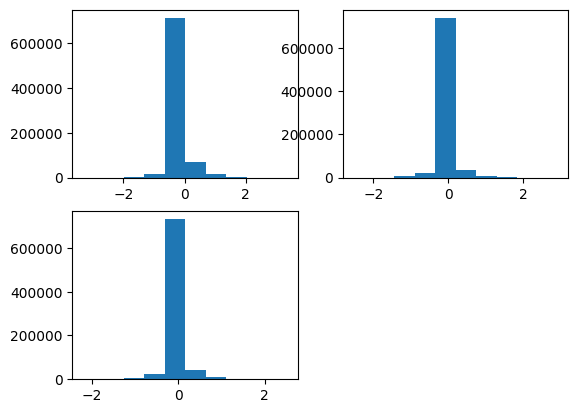

In [173]:
pca = PCA(n_components=3)
scaler = MinMaxScaler(clip=True)
patch_size = dinov2_vits14.patch_size

patch_h  = 224//patch_size
patch_w  = 224//patch_size
feat_dim = 384

total_features = train_features.reshape(train_features.shape[0] * patch_h * patch_w, feat_dim) #4(*H*w, 1024)
total_features = total_features.cpu()

pca.fit(total_features)
pca_features = pca.transform(total_features)

# visualize PCA components for finding a proper threshold
# 3 histograms for 3 components
plt.subplot(2, 2, 1)
plt.hist(pca_features[:, 0])
plt.subplot(2, 2, 2)
plt.hist(pca_features[:, 1])
plt.subplot(2, 2, 3)
plt.hist(pca_features[:, 2])
plt.show()
plt.close()

In [189]:
pca.explained_variance_ratio_

array([0.06001524, 0.04171323, 0.03751193])

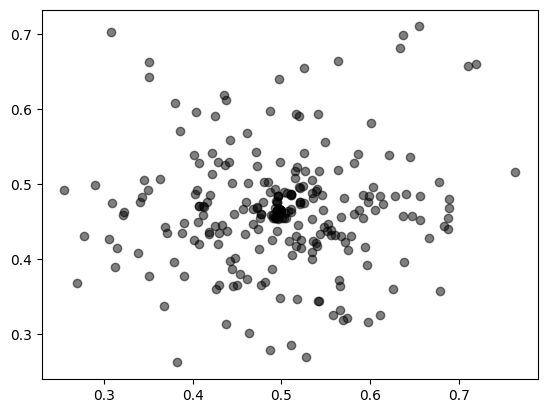

In [188]:
pca_features[:, 0] = (pca_features[:, 0] - pca_features[:, 0].min()) / \
                     (pca_features[:, 0].max() - pca_features[:, 0].min())
pca_features[:, 1] = (pca_features[:, 1] - pca_features[:, 1].min()) / \
                     (pca_features[:, 1].max() - pca_features[:, 1].min())
plt.scatter(pca_features[:1601,0],pca_features[:1601,1],alpha = 0.5,c = 'k')
plt.scatter(pca_features[1601:,0],pca_features[1601:,1],alpha = 0.5,c = 'r')

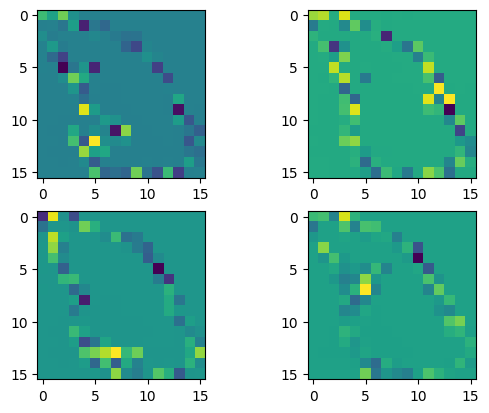

In [176]:
pca_features[:, 0] = (pca_features[:, 0] - pca_features[:, 0].min()) / \
                     (pca_features[:, 0].max() - pca_features[:, 0].min())
# pca_features = sklearn.processing.minmax_scale(pca_features)

for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(pca_features[(i+1660)*patch_h*patch_w : (i+1660+1)*patch_h*patch_w, 0].reshape(patch_h, patch_w))

plt.show()

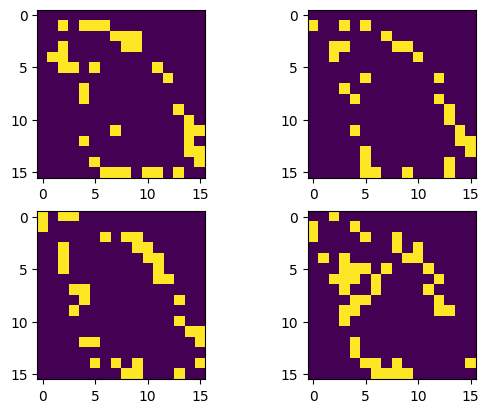

In [179]:
pca_features_bg = pca_features[:, 0] < 0.49 # from first histogram
pca_features_fg = ~pca_features_bg

# plot the pca_features_bg
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(pca_features_bg[(i+1660) * patch_h * patch_w: (i+1660+1) * patch_h * patch_w].reshape(patch_h, patch_w))
plt.show()

Epoch [19/20]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 630.57it/s, loss=0.694]


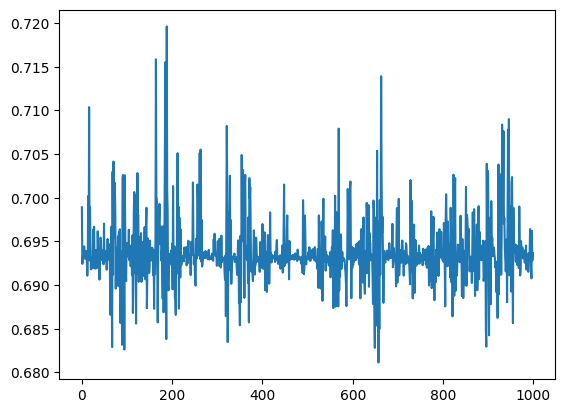

In [206]:
class DinoRegressor(nn.Module):
    def __init__(self):
        super(DinoRegressor, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.classifier(x)
        return x

f_dataset = FeaturesAnglesDataset(train_features, train_labels)
f_loader = DataLoader(f_dataset, batch_size=64, shuffle=True)
    
model = DinoRegressor()
model = model.to(DEVICE)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
model.eval()
num_epoch = 20
losses = []
for epoch in range(num_epoch):
    train_acc = 0
    train_loss = 0
    loop = tqdm(f_loader)
    for features, labels in loop:
        features = features.to(DEVICE).float()
        labels = labels.to(DEVICE).float()

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels.unsqueeze(1))
        losses.append(loss.item())
        predictions = outputs

        loss.backward()
        optimizer.step()

        loop.set_description(f"Epoch [{epoch}/{num_epoch}]")
        loop.set_postfix(loss=loss.item())

plt.plot(losses)

In [190]:
lbs = []
outs = []
with torch.no_grad():
    loop = tqdm(f_loader)
    for features, labels in loop:
        features = features.to(DEVICE).float()
        labels = labels.to(DEVICE).float()
        lbs.append(labels)
        outputs = model(features)
        outs.append(outputs)
labels = torch.cat(lbs)
outputs = torch.cat(outs)
labels = labels.numpy()
outputs = outputs.numpy()
plt.scatter(labels, outputs)

  0%|                                                                                                                                                                                          | 0/50 [00:00<?, ?it/s]


ValueError: not enough values to unpack (expected 4, got 2)

In [198]:
from sklearn.svm import NuSVC
clf = make_pipeline(StandardScaler(), NuSVC())
clf.fit(train_features, train_labels)
print(clf.predict([train_features[1660]]))

[0]


In [203]:
from sklearn.metrics import accuracy_score
outputs = []
labels = []
for i in range(3000):
    outputs.append(clf.predict([train_features[i]]))
    labels.append(train_labels[i].item())
accuracy_score(outputs,labels)

0.9456666666666667

In [6]:
dinov2_vits14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')

class DinoClassifier(nn.Module):
    def __init__(self):
        super(DinoClassifier, self).__init__()
        self.input_proj = nn.Conv2d(20, 3, kernel_size=1)
        self.transformer = dinov2_vits14
        self.transformer.eval()
        for param in self.transformer.parameters():
            param.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )
    
    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        repr = self.transformer.norm(x)
        x = self.classifier(repr)
        return x, repr
    
    def repr(self,x):
        repr = self.transformer.norm(x)
        return repr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = DinoClassifier()
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using cache found in /Users/goldsteyn.kd/.cache/torch/hub/facebookresearch_dinov2_main
/Users/goldsteyn.kd/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/goldsteyn.kd/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/goldsteyn.kd/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [7]:
def train(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, correct = 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y.argmax(1)).sum().item()
    return total_loss / len(dataloader.dataset), correct / len(dataloader.dataset)

for epoch in range(10):
        loss, acc = train(model, dataloader, criterion, optimizer, device)
        print(f"Epoch {epoch+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

Epoch 1: Loss=3.8332, Accuracy=0.4320
Epoch 2: Loss=2.7779, Accuracy=0.3310
Epoch 3: Loss=0.8880, Accuracy=0.6260
Epoch 4: Loss=0.1541, Accuracy=0.9690
Epoch 5: Loss=0.0580, Accuracy=0.9970
Epoch 6: Loss=0.0631, Accuracy=0.9950
Epoch 7: Loss=0.0394, Accuracy=0.9970
Epoch 8: Loss=0.0251, Accuracy=0.9990
Epoch 9: Loss=0.0331, Accuracy=0.9990
Epoch 10: Loss=0.0218, Accuracy=0.9990


In [29]:
def get_repr(model, dataloader, device):
    model.eval()
    reprs = []
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            _, repr = model(x)
            reprs.append(repr)

    reprs = torch.cat(reprs)
    return reprs

reprs = get_repr(model, dataloader, device)

In [30]:
print(reprs.shape)

torch.Size([5001, 384])


In [31]:
np.save('./LatentReprBar.npy', reprs.detach().numpy())

In [3]:
res = np.load('../data/VAEB-426/Bar/latent.npy')
res = np.transpose(res, (0, 4, 2, 3, 1))
res = np.squeeze(res, axis = 4)

'''
tmp = np.load('../data/VAEB-426/Shelf/latent.npy')
tmp = np.transpose(tmp, (0, 4, 2, 3, 1))
tmp = np.squeeze(tmp, axis = 4)
tmp = tmp[:250]
res = np.concatenate((res,tmp),axis=0)

tmp = np.load('../data/VAEB-426/Tidal/latent.npy')
tmp = np.transpose(tmp, (0, 4, 2, 3, 1))
tmp = np.squeeze(tmp, axis = 4)
tmp = tmp[:250]
res = np.concatenate((res,tmp),axis=0)

tmp = np.load('../data/VAEB-426/WD/latent.npy')
tmp = np.transpose(tmp, (0, 4, 2, 3, 1))
tmp = np.squeeze(tmp, axis = 4)
tmp = tmp[:250]
res = np.concatenate((res,tmp),axis=0)
'''
print(res.shape)

(5001, 20, 150, 144)


In [26]:
#labels_list = [0 for i in range(250)] + [1 for i in range(250)] + [2 for i in range(250)] + [3 for i in range(250)]
labels_list = [0 for i in range(5001)]
labels = np.array(labels_list)
n_values = 4
labels = np.eye(n_values)[labels_list]
print(labels.shape)
np.save('./labels.npy',labels)

(5001, 4)


In [24]:
import torch.nn.functional as F

class TensorTransform:
    def __init__(self, target_size=(224, 224), mean=0.5, std=0.5):
        self.target_size = target_size
        self.mean = mean
        self.std = std

    def __call__(self, x):
        # Resize (use bilinear interpolation for tensors)
        x = F.interpolate(x.unsqueeze(0), size=self.target_size, mode='bilinear', align_corners=False)
        x = x.squeeze(0)

        # Normalize per channel
        mean = torch.tensor(self.mean).view(-1, 1, 1)
        std = torch.tensor(self.std).view(-1, 1, 1)
        x = (x - mean) / std

        return x
'''
transform = TensorTransform(
    target_size=(140, 140),
    mean=[0.5] * 20,
    std=[0.5] * 20
)
'''
transform = MultiCropTransform20Ch(global_size=140, local_size = 60)
class LatentClassesDataset(Dataset):
    def __init__(self, features, classes, transform = None):
        self.data = features
        self.targets = classes
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image = torch.tensor(self.data[idx], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        classes = torch.tensor(self.targets[idx], dtype=torch.float32)
        return image, classes

dataset = LatentClassesDataset(res, labels, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)
"""
def __init__(self, cuts_path, angles_path, transform = None):
        self.data = np.load(cuts_path)
        for i in range(1,self.data.shape[1]):
            self.data[:,i,:,:] = self.data[:,0,:,:]
        self.data = self.data*255
        self.transform = transform
        self.targets = np.load(angles_path)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image = self.data[idx]  
        target = self.targets[idx]
        image = torch.from_numpy(image).float() 
        if self.transform:
            image = self.transform(image)
        return image, target
"""
dataset[0][0][0].shape

torch.Size([20, 140, 140])

In [23]:
import torch
import torch.nn.functional as F
import random

class MultiCropTransform20Ch:
    def __init__(self, global_size=224, local_size=96, num_channels = 20, mean=None, std=None):
        self.global_size = global_size
        self.local_size = local_size

        # Default mean/std for 20 channels
        self.mean = torch.tensor(mean if mean is not None else [0.5] * num_channels).view(-1, 1, 1)
        self.std = torch.tensor(std if std is not None else [0.5] * num_channels).view(-1, 1, 1)

    def random_resized_crop(self, img, size):
        C, H, W = img.shape
        scale = random.uniform(0.08, 1.0)
        target_area = scale * H * W
        aspect_ratio = random.uniform(3/4, 4/3)
        new_w = int(round((target_area * aspect_ratio) ** 0.5))
        new_h = int(round((target_area / aspect_ratio) ** 0.5))

        if new_w > W or new_h > H:
            new_w = min(new_w, W)
            new_h = min(new_h, H)

        top = random.randint(0, H - new_h)
        left = random.randint(0, W - new_w)
        cropped = img[:, top:top + new_h, left:left + new_w]
        resized = F.interpolate(cropped.unsqueeze(0), size=(size, size), mode='bilinear', align_corners=False).squeeze(0)
        return resized

    def random_horizontal_flip(self, img):
        return img.flip(-1) if random.random() > 0.5 else img

    def gaussian_blur(self, img, kernel_size=3):
        padding = kernel_size // 2
        channels = img.shape[0]
        kernel = torch.tensor([1., 2., 1.], dtype=torch.float32)
        kernel = kernel[:, None] * kernel[None, :]
        kernel = kernel / kernel.sum()
        kernel = kernel.view(1, 1, kernel_size, kernel_size).repeat(channels, 1, 1, 1)

        img = img.unsqueeze(0)
        blurred = F.conv2d(img, kernel.to(img.device), padding=padding, groups=channels)
        return blurred.squeeze(0)

    def color_jitter(self, img, brightness=0.4, contrast=0.4):
        # Simulate basic brightness and contrast jitter (per image, not per channel)
        if brightness > 0:
            factor = random.uniform(max(0, 1 - brightness), 1 + brightness)
            img = img * factor
        if contrast > 0:
            mean = img.mean(dim=(1, 2), keepdim=True)
            factor = random.uniform(max(0, 1 - contrast), 1 + contrast)
            img = (img - mean) * factor + mean
        return img

    def normalize(self, img):
        return (img - self.mean.to(img.device)) / self.std.to(img.device)

    def transform(self, img, size, blur_kernel):
        img = self.random_resized_crop(img, size)
        img = self.random_horizontal_flip(img)
        img = self.color_jitter(img, brightness=0.4, contrast=0.4)
        img = self.gaussian_blur(img, kernel_size=blur_kernel)
        img = self.normalize(img)
        return img

    def __call__(self, img):
        # img: Tensor (20, H, W)
        return [
            self.transform(img, self.global_size, blur_kernel=3),
            self.transform(img, self.global_size, blur_kernel=3),
            self.transform(img, self.local_size, blur_kernel=3),
            self.transform(img, self.local_size, blur_kernel=3),
        ]